# Paramount Seating Two/Four top

###  Bus 36109 "Advanced Decision Modeling with Python", Don Eisenstein
Don Eisenstein &copy; Copyright 2023, University of Chicago 

---

The Paramount Restaurant is a Boston institution.  Dine-in customers are known to line up for an hour on busy weekends for brunch.   They are investigating the use of Take-Out/Delivery orders. Take-Out orders jump to the front of the line for the cooks, and do not require seating.  Management is worried about the impact Take-out will have on their regular Dine-in customers.

In this initial Paramount Simulation we assume the following.  

- The unit of time is 1 second
- TAKE_OUT_PERCENT is the average proportion of customers that order TAKE_OUT 
- Dine-in Customers arrive according to an exponential distribution with mean `MEAN_TIME_BETWEEN_ARRIVALS` time units between them
- Dine-in customers then queue for one of `NUM_COOKS`
- Take-out orders also queue for a cook, but jump to the front of the line.
- It takes one cook an exponentially distributed time with mean `MEAN_COOK_TIME_DURATION` time untis to prepare one the food order of one Dine-in customer or Take-out customer
- Dine-In customeers then queue for one of `NUM_SEATS`
- The time it takes one Dine-in customer to eat and vacate a seat follows a Uniform(`LOW_EATING_DURATION`,`HIGH_EATING_DURATION`) distribted floating point time units. 
- Run the simulation for `SIM_LENGTH` time units 

Simplifying assumtion:

- We assume communal seating, that is, each customer sits at communal tables with no regard to party/table size. 

Hint:

- To enable Take-Out customers to jump to the head of the line for a Cook, use the `priority` attribute setting for each Entity

## Part 3: Seating

We now consider that customers arrive in a party of size Two or Four.  Assume that a single cook will prepare the food for the entire party.  After the food is prepared the party will then queue accordingly for a Two-Top or Four-Top table.  `PARTY_SIZE_TWO_PERCENTAGE` of the parties are of size Two, and the remaining are of size Four.

There are `NUM_TWO_TOPS` and `NUM_FOUR_TOPS` of each table type.

- Add a threshold policy to your notebook that will seat a 2-party at a Four-Top if at least some threshold value of Four-Tops is empty.
- Plot the Four-Top Empty Threshold value (0..7) vs. the Average Wait Time per PERSON  
- Compute the table utlizations for Two Tops, and Four Tops

---

In [24]:
import numpy as np
import simpy
from simpy_helpers import Entity, Resource, Source, Stats

In [25]:
# New Params for 2/4 top seating
SIM_LENGTH = 488000 # 8 hours 
TAKE_OUT_PERCENTAGE = 0.30
MEAN_TIME_BETWEEN_ARRIVALS = 150
NUM_COOKS = 4
MEAN_COOK_TIME_DURATION = 140 
LOW_EATING_DURATION = 1000
HIGH_EATING_DURATION = 2000
#
#  New Seating Parms
#
NUM_TWO_TOPS = 5 
NUM_FOUR_TOPS = 7 
PARTY_SIZE_TWO_PERCENTAGE = 0.35    # The rest are of size Four 
NUM_FOUR_TOP_EMPTY_THRESHOLD = 2 

**1. Define your Source class**

In [26]:
# Here is the Source subclass
class GenerateParties(Source):
    def interarrival_time(self):
        return np.random.exponential(MEAN_TIME_BETWEEN_ARRIVALS)
    
    def build_entity(self):
        attributes = {}
        
        #  Take out or Dine in?
        customer_type = np.random.choice(["take_out", "dine_in"], p=[TAKE_OUT_PERCENTAGE,(1.0-TAKE_OUT_PERCENTAGE)])
        attributes["customer_type"] = customer_type
        
        if customer_type == "take_out":
            attributes["priority"] = 0 
            
        #  Two or Four top?
        party_size = np.random.choice([2, 4], p=[PARTY_SIZE_TWO_PERCENTAGE,(1.0-PARTY_SIZE_TWO_PERCENTAGE)])
        attributes["party_size"] = party_size
        
        return Party(env, attributes) 

In [27]:
# Return True/False if a two-top party should join four-top resource 
def two_top_party_should_queue_for_four_top():
    
    if two_top.count < NUM_TWO_TOPS:   # a two top table is available
        return False
    
    num_empty_four_tops = NUM_FOUR_TOPS - four_top.count
    if num_empty_four_tops > NUM_FOUR_TOP_EMPTY_THRESHOLD:
        return True
    
    return False

In [ ]:
**2. Define your Entity class**

In [28]:
## Here is the Entity Subclass
class Party(Entity):
    def process(self):
        yield self.wait_for_resource(cook)
        yield self.process_at_resource(cook)
        self.release_resource(cook)
        
        if self.attributes["customer_type"] == "dine_in":
            if self.attributes["party_size"] == 2 and not two_top_party_should_queue_for_four_top():
                yield self.wait_for_resource(two_top)
                yield self.process_at_resource(two_top)
                self.release_resource(two_top)
            else:
                yield self.wait_for_resource(four_top)
                yield self.process_at_resource(four_top)
                self.release_resource(four_top)

**3. Define your Resource classes**

In [29]:
# Here is the Resource subclass
class Cooks(Resource):
    def service_time(self, entity):
        return np.random.exponential(MEAN_COOK_TIME_DURATION, entity.attributes["party_size"]).sum()
    
class TwoTops(Resource):
    def service_time(self, entity):
        return np.random.uniform(LOW_EATING_DURATION, HIGH_EATING_DURATION, entity.attributes["party_size"]).max()
    
class FourTops(Resource):
    def service_time(self, entity):
        # handles 2 or 4 party at four-top 
        return np.random.uniform(LOW_EATING_DURATION, HIGH_EATING_DURATION, entity.attributes["party_size"]).max()

In [ ]:
**4. Run your Simulation.**

In [30]:
np.random.seed(429) 
env = simpy.Environment()

two_top = TwoTops(env, capacity=NUM_TWO_TOPS) 
four_top = FourTops(env, capacity=NUM_FOUR_TOPS) 
cook = Cooks(env, capacity=NUM_COOKS) 
source = GenerateParties(env) 


env.process(source.start(debug=False))
env.run(until=SIM_LENGTH)

**5. Output the following statistics:**
- Average waiting time for Cooks
- Average waiting time for Two Tops 
- Average waiting time for Four Tops 
- Average eating time for Two Tops 
- Average eating time for Four Tops 


In [31]:
print("Average waiting time for Cooks", np.mean(Stats.get_waiting_times(cook)))
print("\n")
print("Average waiting time for Two Tops", np.mean(Stats.get_waiting_times(two_top)))
print("Average waiting time for Four Tops", np.mean(Stats.get_waiting_times(four_top)))
print("\n")
print("Average eating/processing time for Two Tops", np.mean(Stats.get_processing_times(two_top)))
print("Average eating/processing time for Four Tops", np.mean(Stats.get_processing_times(four_top)))
print("\n")


Average waiting time for Cooks 133.39907873688503


Average waiting time for Two Tops 83.31728485700957
Average waiting time for Four Tops 134.69323960740894


Average eating/processing time for Two Tops 1670.684778914213
Average eating/processing time for Four Tops 1803.015767609999




### Challenge:   Plot EMPTY Threshold vs. Average Wait Time per PERSON

NOTE: `[1,2,3] + [6,5,4]` yields a new list: `[1,2,3,6,5,4]`

NOTE:  In code below,  `average_wait_time = ??? ` needs to be completed

FOUR TOP EMPTY THRESHOLD: 0
   Avg Wait Time: 201.081481019989
FOUR TOP EMPTY THRESHOLD: 1
   Avg Wait Time: 202.03539323471807
FOUR TOP EMPTY THRESHOLD: 2
   Avg Wait Time: 194.12972186586464
FOUR TOP EMPTY THRESHOLD: 3
   Avg Wait Time: 187.75768498250835
FOUR TOP EMPTY THRESHOLD: 4
   Avg Wait Time: 197.29696801247093
FOUR TOP EMPTY THRESHOLD: 7
   Avg Wait Time: 206.75572731977942


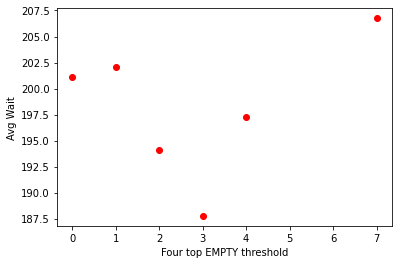

In [32]:
import matplotlib.pyplot as plt
SIM_LENGTH = 488000 # 8 hours 
TAKE_OUT_PERCENTAGE = 0.30
MEAN_TIME_BETWEEN_ARRIVALS = 150
NUM_COOKS = 4
MEAN_COOK_TIME_DURATION = 140 
LOW_EATING_DURATION = 1000
HIGH_EATING_DURATION = 2000
NUM_TWO_TOPS = 5 
NUM_FOUR_TOPS = 7 
PARTY_SIZE_TWO_PERCENTAGE = 0.35    # The rest are of size Four 

np.random.seed(189) 

num_four_top_empty_threshold_iterates = [0, 1, 2, 3, 4, NUM_FOUR_TOPS]
average_wait_times_for_table = []
num_runs = 50 

for NUM_FOUR_TOP_EMPTY_THRESHOLD in num_four_top_empty_threshold_iterates: 
    print(f"FOUR TOP EMPTY THRESHOLD: {NUM_FOUR_TOP_EMPTY_THRESHOLD}")
    each_run = []
    
    for i in range(num_runs):
        env = simpy.Environment()

        two_top = TwoTops(env, capacity=NUM_TWO_TOPS) 
        four_top = FourTops(env, capacity=NUM_FOUR_TOPS) 
        cook = Cooks(env, capacity=NUM_COOKS) 
        source = GenerateParties(env) 

        env.process(source.start(debug=False))
        env.run(until=SIM_LENGTH)

        # compute wait times per person, not per party
        average_wait_time = np.mean(
            Stats.get_waiting_times(two_top, attributes={'party_size': 2}) +
            Stats.get_waiting_times(two_top, attributes={'party_size': 2}) +
            Stats.get_waiting_times(four_top, attributes={'party_size': 2}) +
            Stats.get_waiting_times(four_top, attributes={'party_size': 2}) +
            Stats.get_waiting_times(four_top, attributes={'party_size': 4}) + 
            Stats.get_waiting_times(four_top, attributes={'party_size': 4}) + 
            Stats.get_waiting_times(four_top, attributes={'party_size': 4}) + 
            Stats.get_waiting_times(four_top, attributes={'party_size': 4}) )
        
        each_run.append(average_wait_time)
                
    print(f"   Avg Wait Time: {np.mean(each_run)}")
    average_wait_times_for_table.append(np.mean(each_run))
  
    
plt.plot(num_four_top_empty_threshold_iterates, average_wait_times_for_table,'ro')
plt.xlabel('Four top EMPTY threshold');
plt.ylabel('Avg Wait');
plt.show()

### Challenge:  Computing table utilizations

#### Use the following parameters


In [33]:
# Lets repeat a more central threshold run
NUM_FOUR_TOP_EMPTY_THRESHOLD = 3
env = simpy.Environment()

two_top = TwoTops(env, capacity=NUM_TWO_TOPS) 
four_top = FourTops(env, capacity=NUM_FOUR_TOPS) 
cook = Cooks(env, capacity=NUM_COOKS) 
source = GenerateParties(env) 
env.process(source.start(debug=False))
env.run(until=SIM_LENGTH)

### Table Utilization

One way to compute table utilization is to consider the total seat-hours occupied divided by total seat-hours available.

### CHALLENGE:  Compute 2 top utilization

In [34]:
# (Total seat time occupied) / (Total seat time available)
total_2_top_seat_time_occupied = np.sum(Stats.get_processing_times(two_top))*2.0
total_2_top_seat_time_available = SIM_LENGTH * NUM_TWO_TOPS * 2.0 
print(f"Avg utilization 2 top: { total_2_top_seat_time_occupied/total_2_top_seat_time_available }")

Avg utilization 2 top: 0.5563839657193994


In [35]:
# You could use:
# (average number of seats processed over time) / (num two top seats available) 
# But the above is I think easier, and applies to 4 tops as well.
print(f"Number of 2 tops: {NUM_TWO_TOPS}")
avg_num_parties_processed_over_time_two_top = np.mean(Stats.number_being_processed_over_time(two_top))
avg_num_seats_processed_over_time_two_top = 2*np.mean(Stats.number_being_processed_over_time(two_top))
print(f"Avg num seats processed over time in 2 top: {avg_num_seats_processed_over_time_two_top}")
print(f"Avg utilization 2 top: {avg_num_seats_processed_over_time_two_top/(2*NUM_TWO_TOPS)}")

Number of 2 tops: 5
Avg num seats processed over time in 2 top: 5.563865647816296
Avg utilization 2 top: 0.5563865647816295


### Challenge:  Compute 4 top utilization


In [36]:
# processing times based on each seat 
total_4_top_seat_time_occupied_2_party  = np.sum(Stats.get_processing_times(four_top,attributes={'party_size': 2})) * 2.0
total_4_top_seat_time_occupied_4_party  = np.sum(Stats.get_processing_times(four_top,attributes={'party_size': 4})) * 4.0
total_4_top_seat_time_occupied =  total_4_top_seat_time_occupied_2_party + total_4_top_seat_time_occupied_4_party

print("\n")
print("Total seat time for Four Tops", total_4_top_seat_time_occupied)
print("Total seat time for Four Tops (2-Party)", total_4_top_seat_time_occupied_2_party)
print("Total seat time for Four Tops (4-Party)", total_4_top_seat_time_occupied_4_party)

# total four top seat time available during simulation 
total_4_top_seat_time_available = SIM_LENGTH * NUM_FOUR_TOPS * 4.0

print("\n")
print("Total available four top seat time", total_4_top_seat_time_available)

print("\n")
print("Four Top Utilization", total_4_top_seat_time_occupied/total_4_top_seat_time_available )



Total seat time for Four Tops 10752932.382546892
Total seat time for Four Tops (2-Party) 28797.263584355154
Total seat time for Four Tops (4-Party) 10724135.118962537


Total available four top seat time 13664000.0


Four Top Utilization 0.7869534823292514
